---
## **1 — Load Splits and Setup**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/flight-delay-predictor/splits'))

['val.csv', 'train.csv', 'test.csv']


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')
import time

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve, roc_curve,
    classification_report
)

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13, 'axes.labelsize': 11})
print('Imports ready.')

Imports ready.


In [3]:
SPLITS_DIR = '/content/drive/MyDrive/flight-delay-predictor/splits'

train = pd.read_csv(f'{SPLITS_DIR}/train.csv')
val   = pd.read_csv(f'{SPLITS_DIR}/val.csv')
test  = pd.read_csv(f'{SPLITS_DIR}/test.csv')

TARGET = 'TARGET'
FEATURES = [c for c in train.columns if c != TARGET]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Features: {len(FEATURES)}')
print(f'Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Delay rates — Train: {y_train.mean():.3f}  Val: {y_val.mean():.3f}  Test: {y_test.mean():.3f}')
print(f'\nFeatures:')
for f in FEATURES:
    print(f'  {f}')

Features: 31
Train: 154,458  |  Val: 45,541  |  Test: 100,001
Delay rates — Train: 0.189  Val: 0.161  Test: 0.172

Features:
  MONTH
  DAY_OF_WEEK
  HOUR
  IS_WEEKEND
  SEASON
  LOG_DISTANCE
  temp
  precip
  snowfall
  wind_speed
  wind_gusts
  weather_code
  IS_FREEZING
  IS_RAINING
  IS_SNOWING
  IS_ADVERSE_WEATHER
  ORIGIN_CONGESTION
  DEST_CONGESTION
  TURNAROUND_MIN
  PREV_LEG_DEP_DELAY
  PREV_LEG_DELAYED
  AIRLINE_ROLL7_DELAY
  ORIGIN_AIRPORT_ROLL7_DELAY
  AIRLINE_RATE
  ORIGIN_RATE
  DEST_RATE
  ROUTE_RATE
  ROUTE_SEASON_RATE
  AIRLINE_MONTH_RATE
  ORIGIN_HOUR_RATE
  PREV_LEG_ARR_DELAY


---
## **2 — Helper Functions**

In [ ]:
def find_best_threshold(y_true, y_proba):
    """Sweep the precision-recall curve and return the threshold that maximises F1.

    Used in place of the default 0.5 cutoff because the dataset is imbalanced
    (~19% positive class). The +1e-8 in the denominator avoids divide-by-zero
    at edge thresholds where precision or recall collapse to zero.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_proba)
    f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-8)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]


def evaluate_model(name, y_true, y_proba, threshold):
    """Compute the headline scorecard metrics for one model at a given threshold."""
    y_pred = (y_proba >= threshold).astype(int)
    return {
        'Model': name,
        'Threshold': threshold,
        'F1': f1_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'PR-AUC': average_precision_score(y_true, y_proba),
        'ROC-AUC': roc_auc_score(y_true, y_proba),
    }


def plot_confusion_matrix(y_true, y_proba, threshold, title):
    """Render a 2x2 confusion matrix and print the FN / FP rates underneath."""
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(cm, cmap='Blues')
    labels = ['On-Time', 'Delayed']
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            colour = 'white' if cm[i, j] > cm.max() / 2 else 'black'
            ax.text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                    fontsize=14, fontweight='bold', color=colour)
    plt.tight_layout()
    plt.show()
    tn, fp, fn, tp = cm.ravel()
    print(f'  TP={tp:,}  FP={fp:,}  TN={tn:,}  FN={fn:,}')
    print(f'  Missed delays (FN): {fn:,} / {fn+tp:,} = {fn/(fn+tp):.1%}')

print('Helpers defined.')

---
## **4 — Random Forest**

In [ ]:
# Exhaustive grid search over RF hyperparameters, scored on average precision
# (PR-AUC) to prioritise the minority delayed class. 5-fold cross-validation
# on the training split only — validation and test are never seen here.
rf_param_grid = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20],
    'min_samples_leaf': [4, 6, 8],
    'max_samples': [0.8, 0.9],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', None],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5, scoring='average_precision',
    n_jobs=-1, verbose=1, refit=True
)

n_combos = np.prod([len(v) for v in rf_param_grid.values()])
print(f'RF grid: {n_combos} combinations × 5 folds = {n_combos*5} fits')
print('Training...')

t0 = time.time()
rf_grid.fit(X_train, y_train)
rf_time = time.time() - t0

print(f'\nDone in {rf_time:.0f}s')
print(f'Best params: {rf_grid.best_params_}')
print(f'Best CV PR-AUC: {rf_grid.best_score_:.4f}')

In [ ]:
# RF candidate #1 — shallow trees (max_depth=10).
# Underfit baseline used to size the F1 / PR-AUC ceiling we're trying to beat.
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=10,
    min_samples_leaf=6,
    max_features='sqrt',
    max_samples=0.9,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_proba_val = rf_model.predict_proba(X_val)[:, 1]

# Threshold maximises F1 on the precision-recall curve, locked from validation only.
rf_threshold, rf_best_f1 = find_best_threshold(y_val, rf_proba_val)
print(f"RF Optimal Threshold: {rf_threshold:.4f} (Validation F1: {rf_best_f1:.4f})")

rf_proba_train = rf_model.predict_proba(X_train)[:, 1]

# Train vs val gap diagnoses overfitting before settling on a final config.
print(f"RF Train PR-AUC: {average_precision_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   PR-AUC: {average_precision_score(y_val, rf_proba_val):.4f}")
print(f"RF Train ROC-AUC: {roc_auc_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   ROC-AUC: {roc_auc_score(y_val, rf_proba_val):.4f}")

In [ ]:
# RF candidate #2 — deep trees (max_depth=20).
# Capacity stress test: if the gap between train and val PR-AUC widens
# substantially here, the deeper trees are memorising rather than generalising.
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_leaf=6,
    max_features='sqrt',
    max_samples=0.9,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_proba_val = rf_model.predict_proba(X_val)[:, 1]
rf_threshold, rf_best_f1 = find_best_threshold(y_val, rf_proba_val)
print(f"RF Optimal Threshold: {rf_threshold:.4f} (Validation F1: {rf_best_f1:.4f})")

rf_proba_train = rf_model.predict_proba(X_train)[:, 1]

print(f"RF Train PR-AUC: {average_precision_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   PR-AUC: {average_precision_score(y_val, rf_proba_val):.4f}")
print(f"RF Train ROC-AUC: {roc_auc_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   ROC-AUC: {roc_auc_score(y_val, rf_proba_val):.4f}")

In [ ]:
# RF candidate #3 — final config (max_depth=15).
# Sweet spot between candidates #1 and #2, picked by F1 on the validation set
# while keeping the train/val PR-AUC gap reasonable. This is the persisted RF.
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_leaf=6,
    max_features='sqrt',
    max_samples=0.9,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_proba_val = rf_model.predict_proba(X_val)[:, 1]
rf_threshold, rf_best_f1 = find_best_threshold(y_val, rf_proba_val)
print(f"RF Optimal Threshold: {rf_threshold:.4f} (Validation F1: {rf_best_f1:.4f})")

print(f"RF Train PR-AUC: {average_precision_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   PR-AUC: {average_precision_score(y_val, rf_proba_val):.4f}")
print(f"RF Train ROC-AUC: {roc_auc_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   ROC-AUC: {roc_auc_score(y_val, rf_proba_val):.4f}")

In [21]:
import joblib

joblib.dump(rf_model, '/content/drive/MyDrive/flight-delay-predictor/rf_model.pkl')
joblib.dump(rf_threshold, '/content/drive/MyDrive/flight-delay-predictor/rf_threshold.pkl')
print('RF model and threshold saved.')

RF model and threshold saved.


In [ ]:
rf_proba_train = rf_model.predict_proba(X_train)[:, 1]

print(f"RF Train PR-AUC: {average_precision_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   PR-AUC: {average_precision_score(y_val, rf_proba_val):.4f}")
print(f"RF Train ROC-AUC: {roc_auc_score(y_train, rf_proba_train):.4f}")
print(f"RF Val   ROC-AUC: {roc_auc_score(y_val, rf_proba_val):.4f}")

---
## **5 — XGBoost**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# scale_pos_weight: optional XGBoost knob that re-weights the positive class
# during training. Computed as neg/pos so the grid can compare automatic
# class re-weighting against the threshold-tuning approach (scale_pos_weight=1.0).
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
base_spw = round(neg / pos, 2)

# Grid is wider than RF because XGBoost has more independent levers.
# Same scoring (PR-AUC) and 5-fold CV on training data only.
xgb_param_grid = {
    'n_estimators': [300, 600, 900],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6, 8],
    'min_child_weight': [3, 5],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'gamma': [0, 0.1],
    'reg_alpha': [0.1, 0.5],
    'scale_pos_weight': [1.0, base_spw],
}

xgb_grid = GridSearchCV(
    XGBClassifier(
        objective='binary:logistic',
        random_state=42,
        eval_metric='aucpr',
        tree_method='hist',
        device='cuda',
        n_jobs=1
    ),
    xgb_param_grid,
    cv=5,
    scoring='average_precision',
    n_jobs=1,
    verbose=2,
    refit=True
)

n_combos = np.prod([len(v) for v in xgb_param_grid.values()])
print(f'Combinations: {n_combos} × 5 = {n_combos*5} fits')
print(f'Base scale_pos_weight: {base_spw}')
xgb_grid.fit(X_train, y_train)
print(f'Best params: {xgb_grid.best_params_}')
print(f'Best CV PR-AUC: {xgb_grid.best_score_:.4f}')

In [ ]:
# XGB candidate #1 — conservative settings (shallow, low learning rate).
# Mirrors the RF candidate-1 role: an underfit baseline.
xgb_best = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    scale_pos_weight=1.0,
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',
    device='cuda',
    verbosity=0
)
xgb_best.fit(X_train, y_train)

xgb_proba_val = xgb_best.predict_proba(X_val)[:, 1]
xgb_threshold, xgb_best_f1 = find_best_threshold(y_val, xgb_proba_val)
print(f"XGB Optimal Threshold: {xgb_threshold:.4f} (Validation F1: {xgb_best_f1:.4f})")

In [10]:
xgb_proba_train = xgb_best.predict_proba(X_train)[:, 1]

print(f"XGB Train PR-AUC: {average_precision_score(y_train, xgb_proba_train):.4f}")
print(f"XGB Val   PR-AUC: {average_precision_score(y_val, xgb_proba_val):.4f}")
print(f"XGB Train ROC-AUC: {roc_auc_score(y_train, xgb_proba_train):.4f}")
print(f"XGB Val   ROC-AUC: {roc_auc_score(y_val, xgb_proba_val):.4f}")

XGB Train PR-AUC: 0.5369
XGB Val   PR-AUC: 0.4574
XGB Train ROC-AUC: 0.8115
XGB Val   ROC-AUC: 0.7778


In [ ]:
# XGB candidate #2 — final config (deeper trees, more rounds).
# Best balance of validation F1 and train/val gap; this is the persisted XGB.
xgb_best = XGBClassifier(
    n_estimators=600,
    learning_rate=0.1,
    max_depth=6,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.1,
    scale_pos_weight=1.0,
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',
    device='cuda',
    verbosity=0
)
xgb_best.fit(X_train, y_train)

xgb_proba_val = xgb_best.predict_proba(X_val)[:, 1]
xgb_threshold, xgb_best_f1 = find_best_threshold(y_val, xgb_proba_val)
print(f"XGB Optimal Threshold: {xgb_threshold:.4f} (Validation F1: {xgb_best_f1:.4f})")

In [24]:
xgb_proba_train = xgb_best.predict_proba(X_train)[:, 1]

print(f"XGB Train PR-AUC: {average_precision_score(y_train, xgb_proba_train):.4f}")
print(f"XGB Val   PR-AUC: {average_precision_score(y_val, xgb_proba_val):.4f}")
print(f"XGB Train ROC-AUC: {roc_auc_score(y_train, xgb_proba_train):.4f}")
print(f"XGB Val   ROC-AUC: {roc_auc_score(y_val, xgb_proba_val):.4f}")

XGB Train PR-AUC: 0.7274
XGB Val   PR-AUC: 0.5751
XGB Train ROC-AUC: 0.8998
XGB Val   ROC-AUC: 0.8364


In [ ]:
# Deliberate over-capacity run, used in the train/val gap discussion (Section 5.3).
xgb_best_overfit = XGBClassifier(
    n_estimators=900,
    learning_rate=0.1,
    max_depth=8,
    min_child_weight=7,
    subsample=0.7,
    colsample_bytree=0.7,
    gamma=0.1,
    reg_alpha=0.1,
    scale_pos_weight=1.0,
    random_state=42,
    eval_metric='aucpr',
    tree_method='hist',
    device='cuda',
    verbosity=0
)
xgb_best.fit(X_train, y_train)

xgb_proba_val = xgb_best.predict_proba(X_val)[:, 1]
xgb_threshold, xgb_best_f1 = find_best_threshold(y_val, xgb_proba_val)
print(f"XGB Optimal Threshold: {xgb_threshold:.4f} (Validation F1: {xgb_best_f1:.4f})")

In [17]:
xgb_proba_train = xgb_best.predict_proba(X_train)[:, 1]

print(f"XGB Train PR-AUC: {average_precision_score(y_train, xgb_proba_train):.4f}")
print(f"XGB Val   PR-AUC: {average_precision_score(y_val, xgb_proba_val):.4f}")
print(f"XGB Train ROC-AUC: {roc_auc_score(y_train, xgb_proba_train):.4f}")
print(f"XGB Val   ROC-AUC: {roc_auc_score(y_val, xgb_proba_val):.4f}")

XGB Train PR-AUC: 0.9558
XGB Val   PR-AUC: 0.7457
XGB Train ROC-AUC: 0.9869
XGB Val   ROC-AUC: 0.9025


In [25]:
import joblib

joblib.dump(xgb_best, '/content/drive/MyDrive/flight-delay-predictor/xgb_model.pkl')
joblib.dump(xgb_threshold, '/content/drive/MyDrive/flight-delay-predictor/xgb_threshold.pkl')
print('XGB model and threshold saved.')

XGB model and threshold saved.


---
## **6 - FT-Transformer**

In [26]:
!pip install pytorch-tabular optuna -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 20.8 MB/s eta 0:00:00


In [27]:
CONTINUOUS_COLS = [
    'LOG_DISTANCE', 'temp', 'precip', 'snowfall', 'wind_speed', 'wind_gusts',
    'ORIGIN_CONGESTION', 'DEST_CONGESTION', 'TURNAROUND_MIN',
    'PREV_LEG_DEP_DELAY', 'PREV_LEG_ARR_DELAY',
    'AIRLINE_ROLL7_DELAY', 'ORIGIN_AIRPORT_ROLL7_DELAY',
    'AIRLINE_RATE', 'ORIGIN_RATE', 'DEST_RATE', 'ROUTE_RATE',
    'ROUTE_SEASON_RATE', 'AIRLINE_MONTH_RATE', 'ORIGIN_HOUR_RATE'
]

CATEGORICAL_COLS = [
    'MONTH', 'DAY_OF_WEEK', 'HOUR', 'IS_WEEKEND', 'SEASON',
    'weather_code', 'IS_FREEZING', 'IS_RAINING', 'IS_SNOWING',
    'IS_ADVERSE_WEATHER', 'PREV_LEG_DELAYED'
]

TARGET_COL = 'TARGET'

print(f"Continuous features: {len(CONTINUOUS_COLS)}")
print(f"Categorical features: {len(CATEGORICAL_COLS)}")
print(f"Total: {len(CONTINUOUS_COLS) + len(CATEGORICAL_COLS)}")

# Verify all columns exist
all_features = CONTINUOUS_COLS + CATEGORICAL_COLS
missing = [c for c in all_features if c not in train.columns]
print(f"Missing columns: {missing}")

Continuous features: 20
Categorical features: 11
Total: 31
Missing columns: []


In [ ]:
import optuna
import torch
from pytorch_tabular import TabularModel
from pytorch_tabular.models import FTTransformerConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig
from sklearn.metrics import average_precision_score
import warnings
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# pytorch-tabular requires categorical columns as strings so it can build embeddings.
train_ftt = train.copy()
val_ftt = val.copy()
for col in CATEGORICAL_COLS:
    train_ftt[col] = train_ftt[col].astype(str)
    val_ftt[col] = val_ftt[col].astype(str)

In [ ]:
# Optuna search for FT-Transformer hyperparameters.
# TPE sampler is more efficient than grid search for the high-dimensional FTT
# space (embedding dim, attention heads, layer depth, three dropout rates,
# and a log-scaled learning rate).
trial_counter = [0]
torch.set_float32_matmul_precision('medium')

# Static configs reused across every trial — only the model_config changes.
data_config = DataConfig(
    target=[TARGET_COL],
    continuous_cols=CONTINUOUS_COLS,
    categorical_cols=CATEGORICAL_COLS,
)

trainer_config = TrainerConfig(
    max_epochs=150,
    batch_size=1024,
    early_stopping='valid_loss',
    early_stopping_patience=20,
    early_stopping_mode='min',
    accelerator='gpu',
    devices=1,
)

optimizer_config = OptimizerConfig(optimizer='Adam')


def objective(trial):
    """One Optuna trial: sample a config, train, return val PR-AUC."""
    trial_counter[0] += 1
    print(f"\n{'='*50}")
    print(f"Trial {trial_counter[0]}/50")
    print(f"{'='*50}")

    model_config = FTTransformerConfig(
        task='classification',
        input_embed_dim=trial.suggest_categorical('input_embed_dim', [32, 64, 128]),
        num_heads=trial.suggest_categorical('num_heads', [4, 8]),
        num_attn_blocks=trial.suggest_int('num_attn_blocks', 2, 6),
        attn_dropout=trial.suggest_float('attn_dropout', 0.0, 0.3),
        add_norm_dropout=trial.suggest_float('add_norm_dropout', 0.0, 0.3),
        ff_dropout=trial.suggest_float('ff_dropout', 0.0, 0.3),
        learning_rate=trial.suggest_float('learning_rate', 1e-4, 1e-3, log=True),
    )

    try:
        model = TabularModel(
            data_config=data_config,
            model_config=model_config,
            optimizer_config=optimizer_config,
            trainer_config=trainer_config,
        )

        model.fit(train=train_ftt, validation=val_ftt)
        preds = model.predict(val_ftt)
        pr_auc = average_precision_score(
            val_ftt[TARGET_COL],
            preds['TARGET_1_probability']
        )
        print(f"Trial {trial_counter[0]} PR-AUC: {pr_auc:.4f}")
        return pr_auc

    except Exception as e:
        # Trials can fail on degenerate configs (e.g. dropout interactions).
        # Returning 0.0 lets the TPE sampler steer away rather than abort the search.
        print(f"Trial {trial_counter[0]} failed: {e}")
        return 0.0

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
    study_name='ftt_flight_delay'
)

print("Starting Optuna search — 50 trials...")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

In [33]:
print("Top 5 Optuna trials:\n")
trials = sorted(study.trials, key=lambda t: t.value if t.value else 0, reverse=True)
for i, trial in enumerate(trials[:5]):
    print(f"Rank {i+1} | Trial {trial.number} | PR-AUC: {trial.value:.4f}")
    for k, v in trial.params.items():
        print(f"  {k}: {v}")
    print()

Top 5 Optuna trials:

Rank 1 | Trial 15 | PR-AUC: 0.7838
  input_embed_dim: 128
  num_heads: 4
  num_attn_blocks: 6
  attn_dropout: 0.19440560571821563
  add_norm_dropout: 0.0014202595404540913
  ff_dropout: 0.10421799084050395
  learning_rate: 0.0003847841083772163

Rank 2 | Trial 28 | PR-AUC: 0.6875
  input_embed_dim: 64
  num_heads: 4
  num_attn_blocks: 6
  attn_dropout: 0.123474094623314
  add_norm_dropout: 0.17840888386139206
  ff_dropout: 0.20424226186141936
  learning_rate: 0.00031291278768038125

Rank 3 | Trial 10 | PR-AUC: 0.5213
  input_embed_dim: 32
  num_heads: 4
  num_attn_blocks: 6
  attn_dropout: 0.27968710257353613
  add_norm_dropout: 0.08180606316032529
  ff_dropout: 0.06538182813497571
  learning_rate: 0.0004610484183700234

Rank 4 | Trial 24 | PR-AUC: 0.5102
  input_embed_dim: 32
  num_heads: 4
  num_attn_blocks: 6
  attn_dropout: 0.21184541676134377
  add_norm_dropout: 0.28075810518447
  ff_dropout: 0.14317438692973986
  learning_rate: 0.0005823776268653252

Rank 5 

In [ ]:
# Final FT-Transformer — instantiated with the Optuna-best hyperparameters from
# the previous cell and re-trained from scratch with deterministic seeding.
# This is the model persisted to disk and used for all reported test metrics.
import torch
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

trainer_config = TrainerConfig(
    max_epochs=150,
    batch_size=1024,
    early_stopping='valid_loss',
    early_stopping_patience=20,
    early_stopping_mode='min',
    accelerator='gpu',
    devices=1,
)

best_model_config = FTTransformerConfig(
    task='classification',
    input_embed_dim=128,
    num_heads=4,
    num_attn_blocks=6,
    attn_dropout=0.19440560571821563,
    add_norm_dropout=0.0014202595404540913,
    ff_dropout=0.10421799084050395,
    learning_rate=0.0003847841083772163,
)

ftt_model = TabularModel(
    data_config=data_config,
    model_config=best_model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

ftt_model.fit(train=train_ftt, validation=val_ftt)
preds = ftt_model.predict(val_ftt)

# Same threshold-tuning approach as RF / XGB: pick the cutoff that maximises F1
# on the validation set, then lock it for test-time evaluation.
ftt_proba_val = preds['TARGET_1_probability'].values
precisions, recalls, thresholds = precision_recall_curve(val_ftt[TARGET_COL], ftt_proba_val)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
ftt_threshold = thresholds[np.argmax(f1_scores)]

print(f"FTT Optimal Threshold: {ftt_threshold:.4f}")

In [35]:
print(f"FTT Optimal Threshold: {ftt_threshold:.4f}")
print(f"\n=== FT-Transformer — Validation Results ===")
print(classification_report(val_ftt[TARGET_COL], (ftt_proba_val >= ftt_threshold).astype(int),
      target_names=['On Time', 'Delayed']))
print(f"PR-AUC: {average_precision_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")
print(f"ROC-AUC: {roc_auc_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")

FTT Optimal Threshold: 0.4904

=== FT-Transformer — Validation Results ===
              precision    recall  f1-score   support

     On Time       0.94      0.97      0.96     38210
     Delayed       0.81      0.68      0.74      7331

    accuracy                           0.92     45541
   macro avg       0.88      0.82      0.85     45541
weighted avg       0.92      0.92      0.92     45541

PR-AUC: 0.7838
ROC-AUC: 0.8983


In [ ]:
train_preds = ftt_model.predict(train_ftt)
train_proba = train_preds['TARGET_1_probability'].values

# Apply the validation-locked threshold to both splits to expose the train/val gap.
train_labels = (train_proba >= ftt_threshold).astype(int)
val_labels = (ftt_proba_val >= ftt_threshold).astype(int)

print("=== TRAIN SET ===")
print(classification_report(train_ftt[TARGET_COL], train_labels, target_names=['On Time', 'Delayed']))
print(f"PR-AUC: {average_precision_score(train_ftt[TARGET_COL], train_proba):.4f}")
print(f"ROC-AUC: {roc_auc_score(train_ftt[TARGET_COL], train_proba):.4f}")

print("\n=== VAL SET ===")
print(classification_report(val_ftt[TARGET_COL], val_labels, target_names=['On Time', 'Delayed']))
print(f"PR-AUC: {average_precision_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")
print(f"ROC-AUC: {roc_auc_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")

In [ ]:
ftt_model.save_model('/content/drive/MyDrive/flight-delay-predictor/ftt_model')

import joblib
joblib.dump(ftt_threshold, '/content/drive/MyDrive/flight-delay-predictor/ftt_threshold.pkl')

print('FTT model and threshold saved.')

In [ ]:
import torch
torch.manual_seed(42)
torch.cuda.manual_seed(42)
np.random.seed(42)

trainer_config = TrainerConfig(
    max_epochs=300,
    batch_size=1024,
    early_stopping='valid_loss',
    early_stopping_patience=40,
    early_stopping_mode='min',
    accelerator='gpu',
    devices=1,
)

best_model_config = FTTransformerConfig(
    task='classification',
    input_embed_dim=128,
    num_heads=4,
    num_attn_blocks=2,
    attn_dropout=0.1659028016035461,
    add_norm_dropout=0.29432124782679114,
    ff_dropout=0.06467915554076135,
    learning_rate=0.0009398050206015244,
)

ftt_model = TabularModel(
    data_config=data_config,
    model_config=best_model_config,
    optimizer_config=optimizer_config,
    trainer_config=trainer_config,
)

ftt_model.fit(train=train_ftt, validation=val_ftt)
preds = ftt_model.predict(val_ftt)

ftt_proba_val = preds['TARGET_1_probability'].values
precisions, recalls, thresholds = precision_recall_curve(val_ftt[TARGET_COL], ftt_proba_val)
f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
ftt_threshold = thresholds[np.argmax(f1_scores)]

print(f"FTT Optimal Threshold: {ftt_threshold:.4f}")

In [ ]:
print(f"\n=== FT-Transformer — Validation Results ===")
print(classification_report(val_ftt[TARGET_COL], (ftt_proba_val >= ftt_threshold).astype(int),
      target_names=['On Time', 'Delayed']))
print(f"PR-AUC: {average_precision_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")
print(f"ROC-AUC: {roc_auc_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")

In [ ]:
# Check train vs val gap
train_preds = ftt_model.predict(train_ftt)
train_proba = train_preds['TARGET_1_probability'].values

print(f"Train PR-AUC: {average_precision_score(train_ftt[TARGET_COL], train_proba):.4f}")
print(f"Val   PR-AUC: {average_precision_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")
print(f"\nTrain ROC-AUC: {roc_auc_score(train_ftt[TARGET_COL], train_proba):.4f}")
print(f"Val   ROC-AUC: {roc_auc_score(val_ftt[TARGET_COL], ftt_proba_val):.4f}")

Train PR-AUC: 0.9115
Val   PR-AUC: 0.6709

Train ROC-AUC: 0.9706
Val   ROC-AUC: 0.8702


---
## **6 — Validation Comparison**

In [ ]:
# Validation scorecard: compares all three models at their tuned thresholds.
# Highest value in each metric column is highlighted green.
val_results = pd.DataFrame([
    evaluate_model('Random Forest', y_val, rf_proba_val, rf_threshold),
    evaluate_model('XGBoost', y_val, xgb_proba_val, xgb_threshold),
    evaluate_model('FT-Transformer', y_val, ftt_proba_val, ftt_threshold),
])

print('=== VALIDATION SET SCORECARD ===')
display(val_results.style.format({
    'Threshold': '{:.4f}', 'F1': '{:.4f}', 'Precision': '{:.4f}',
    'Recall': '{:.4f}', 'PR-AUC': '{:.4f}', 'ROC-AUC': '{:.4f}'
}).highlight_max(subset=['F1', 'PR-AUC', 'ROC-AUC'], color='#d4edda'))

In [ ]:
# Side-by-side PR and ROC curves on the validation set.
# PR-AUC is the primary metric here (better suited than ROC-AUC for imbalanced
# data); ROC-AUC is shown for cross-comparison with prior literature.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models = [
    ('Random Forest', rf_proba_val, rf_threshold, '#27ae60'),
    ('XGBoost', xgb_proba_val, xgb_threshold, '#e74c3c'),
    ('FT-Transformer', ftt_proba_val, ftt_threshold, '#3498db'),
]

# Precision-recall curves
for name, proba, thresh, colour in models:
    prec, rec, _ = precision_recall_curve(y_val, proba)
    pr_auc = average_precision_score(y_val, proba)
    axes[0].plot(rec, prec, color=colour, linewidth=2, label=f'{name} (AP={pr_auc:.3f})')

axes[0].axhline(y_val.mean(), color='grey', ls=':', lw=1, label=f'Baseline ({y_val.mean():.3f})')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve (Validation)')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

# ROC curves
for name, proba, thresh, colour in models:
    fpr, tpr, _ = roc_curve(y_val, proba)
    auc = roc_auc_score(y_val, proba)
    axes[1].plot(fpr, tpr, color=colour, linewidth=2, label=f'{name} (AUC={auc:.3f})')

axes[1].plot([0,1], [0,1], color='grey', ls=':', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (Validation)')
axes[1].legend(loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

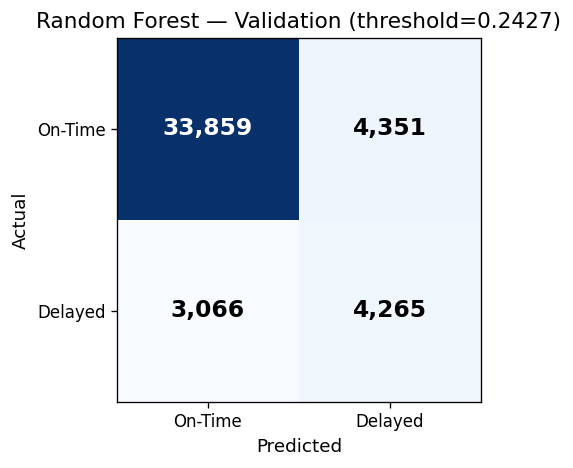

  TP=4,265  FP=4,351  TN=33,859  FN=3,066
  Missed delays (FN): 3,066 / 7,331 = 41.8%


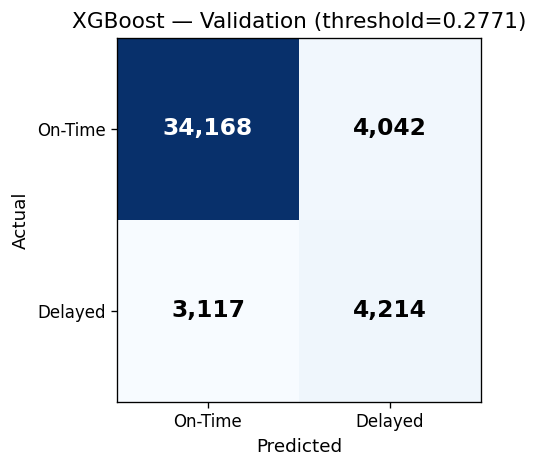

  TP=4,214  FP=4,042  TN=34,168  FN=3,117
  Missed delays (FN): 3,117 / 7,331 = 42.5%


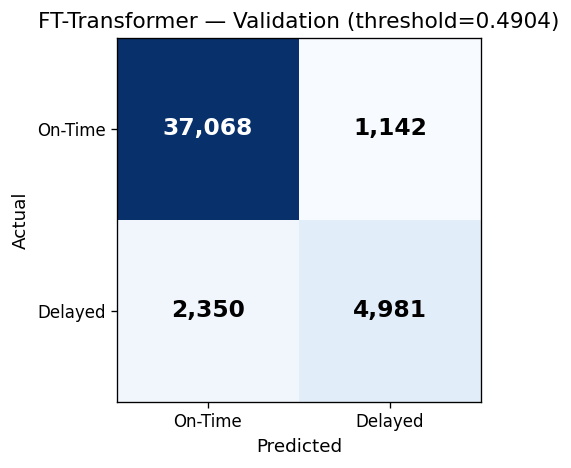

  TP=4,981  FP=1,142  TN=37,068  FN=2,350
  Missed delays (FN): 2,350 / 7,331 = 32.1%


In [44]:
for name, proba, thresh in [
    ('Random Forest', rf_proba_val, rf_threshold),
    ('XGBoost', xgb_proba_val, xgb_threshold),
    ('FT-Transformer', ftt_proba_val, ftt_threshold),
]:
    plot_confusion_matrix(y_val, proba, thresh, f'{name} — Validation (threshold={thresh:.4f})')

---
## **7 — Feature Importance**

In [ ]:
# Native feature-importance plots for the two tree models.
# RF uses Gini-based importance; XGBoost uses gain-based importance — different
# scales but both indicate which features the trees split on most informatively.
# A direct cross-model comparison is in NB05 via permutation importance.
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

rf_imp = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
rf_imp.tail(15).plot.barh(ax=axes[0], color='#27ae60', edgecolor='black', linewidth=0.3)
axes[0].set_title('Random Forest — Top 15 Features')
axes[0].set_xlabel('Importance (Gini)')

xgb_imp = pd.Series(xgb_best.feature_importances_, index=FEATURES).sort_values(ascending=True)
xgb_imp.tail(15).plot.barh(ax=axes[1], color='#e74c3c', edgecolor='black', linewidth=0.3)
axes[1].set_title('XGBoost — Top 15 Features')
axes[1].set_xlabel('Importance (Gain)')

plt.suptitle('Feature Importance Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Side-by-side top 10 makes shared and divergent features easy to spot.
print('\n=== Top 10 Features ===')
top_rf  = rf_imp.sort_values(ascending=False).head(10)
top_xgb = xgb_imp.sort_values(ascending=False).head(10)

comparison = pd.DataFrame({
    'RF Feature': top_rf.index, 'RF Importance': top_rf.values,
    'XGB Feature': top_xgb.index, 'XGB Importance': top_xgb.values,
})
display(comparison)

---
## **8 — Threshold Sensitivity Analysis**

In [ ]:
# Threshold sensitivity for XGBoost — sweeps thresholds from 0.10 to 0.60 and
# tracks F1 / precision / recall. The peak F1 marks the locked threshold;
# the curves above and below it show the trade-off cost of operating at a
# different cutoff (e.g. higher recall at the price of more false alarms).
thresholds_range = np.arange(0.10, 0.60, 0.01)
f1s, precs, recs = [], [], []

for t in thresholds_range:
    preds = (xgb_proba_val >= t).astype(int)
    f1s.append(f1_score(y_val, preds))
    precs.append(precision_score(y_val, preds, zero_division=0))
    recs.append(recall_score(y_val, preds))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, f1s, 'b-', linewidth=2, label='F1')
ax.plot(thresholds_range, precs, 'g--', linewidth=1.5, label='Precision')
ax.plot(thresholds_range, recs, 'r--', linewidth=1.5, label='Recall')
ax.axvline(xgb_threshold, color='black', ls=':', lw=1.5,
           label=f'Optimal threshold ({xgb_threshold:.3f})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('XGBoost — Threshold Sensitivity (Validation Set)')
ax.legend()
ax.set_xlim(0.10, 0.60)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

print(f'Optimal threshold: {xgb_threshold:.4f}')
print(f'At this threshold — F1={f1_score(y_val, (xgb_proba_val >= xgb_threshold).astype(int)):.4f}')